# Survey Overview (Sharing-Eligible Responses)

This notebook loads `survey.csv`, filters to students who agreed their responses can be shared beyond class context, and explores trends with a few visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("survey.csv")
print(f"Loaded {len(df)} responses with {df.shape[1]} columns.")

Loaded 98 responses with 19 columns.


In [2]:
# Locate consent column and build consent flags
consent_col = [c for c in df.columns if c.startswith("This feedback may be valuable")][0]
consent = df[consent_col].fillna("")

consent_opts = {
    "agg_summary": "I consent to my responses being included in anonymous, aggregated summaries.",
    "anon_quotes": "I consent to anonymous direct quotes from my responses being used.",
    "named_use": "I consent to my name being attached to my responses if useful for broader discussion.",
    "follow_up": "I’m open to a follow-up conversation; please contact me."
}

for k, phrase in consent_opts.items():
    df[k] = consent.str.contains(phrase, regex=False)

# "Agreed to share beyond class" definition used here:
# opted into at least one broader sharing option, and did not opt into "do not use outside course context"
df["share_beyond_class"] = (
    (df["agg_summary"] | df["anon_quotes"] | df["named_use"])
)

df_share = df[df["share_beyond_class"]].copy()

print(f"Responses agreeing to share beyond class: {len(df_share)} / {len(df)}")
print("Consent option counts (all responses):")
print(df[["agg_summary", "anon_quotes", "named_use", "follow_up"]].sum().sort_values(ascending=False))

Responses agreeing to share beyond class: 89 / 98
Consent option counts (all responses):
agg_summary    87
anon_quotes    70
follow_up      27
named_use      23
dtype: int64


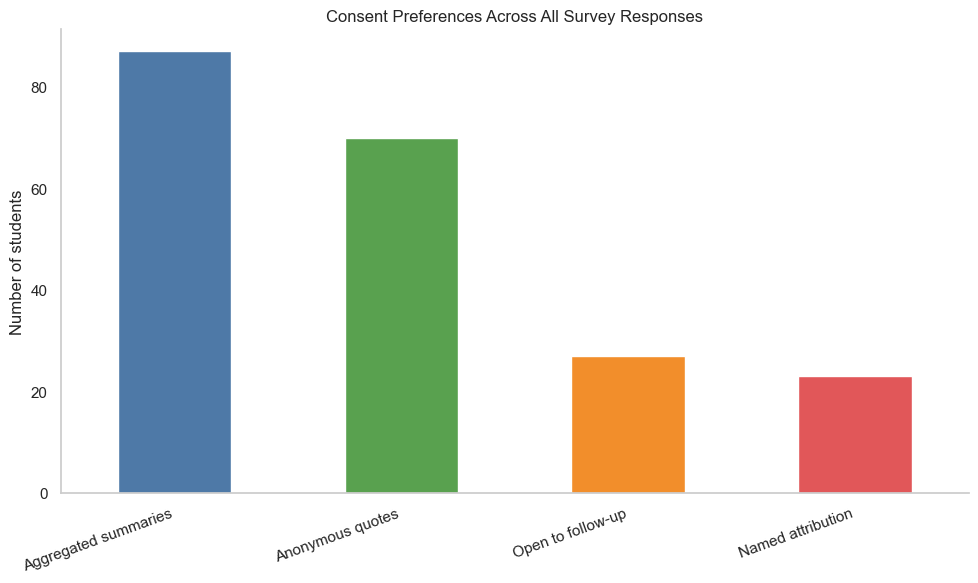

In [3]:
# Plot 1: Consent option uptake across all respondents
consent_counts = df[["agg_summary", "anon_quotes", "named_use", "follow_up"]].sum().sort_values(ascending=False)
labels = {
    "agg_summary": "Aggregated summaries",
    "anon_quotes": "Anonymous quotes",
    "named_use": "Named attribution",
    "follow_up": "Open to follow-up"
}

ax = consent_counts.rename(index=labels).plot(kind="bar", color=["#4E79A7", "#59A14F", "#F28E2B", "#E15759", "#76B7B2"])
ax.set_title("Consent Preferences Across All Survey Responses")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Number of students")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

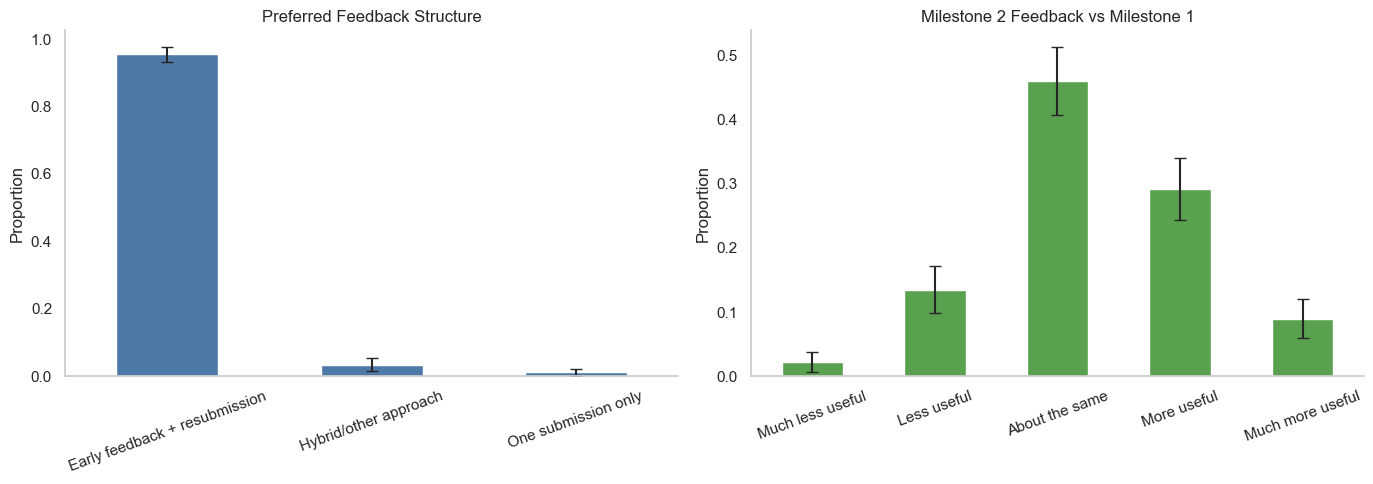

In [4]:
# Plot 2: Distribution of milestone preference and perceived usefulness (sharing-eligible only)
pref_col = "Which feedback structure do you prefer overall for milestones?"
useful_col = "Compared with Milestone 1 feedback, Milestone 2 feedback was:"

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: preferred structure with SE error bars
left_counts = df_share[pref_col].value_counts()
n_left = left_counts.sum()
left_p = left_counts / n_left
left_se = np.sqrt(left_p * (1 - left_p) / n_left)

left_p.plot(kind="bar", ax=axes[0], color="#4E79A7", yerr=left_se, capsize=4)
axes[0].set_title("Preferred Feedback Structure")
axes[0].set_xlabel("")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right: usefulness with SE error bars (ordered)
usefulness_order = ["Much less useful", "Less useful", "About the same", "More useful", "Much more useful"]
right_counts = (
    df_share[useful_col]
    .value_counts()
    .reindex(usefulness_order)
    .fillna(0)
)
n_right = right_counts.sum()
right_p = right_counts / n_right
right_se = np.sqrt(right_p * (1 - right_p) / n_right)

right_p.plot(kind="bar", ax=axes[1], color="#59A14F", yerr=right_se, capsize=4)
axes[1].set_title("Milestone 2 Feedback vs Milestone 1")
axes[1].set_xlabel("")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


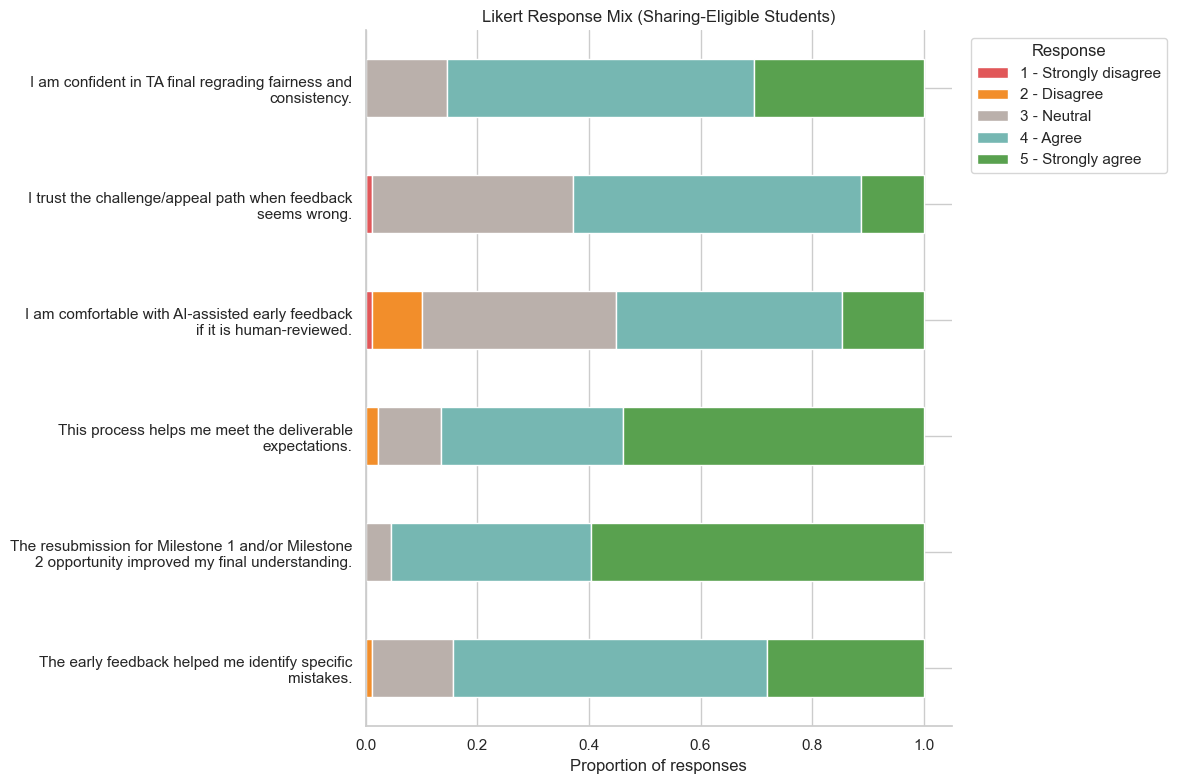

In [5]:
# Plot 3: Likert distributions for key process-confidence statements (sharing-eligible only)
from textwrap import fill

likert_cols = [
    "The early feedback helped me identify specific mistakes.",
    "The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.",
    "This process helps me meet the deliverable expectations.",
    "I am comfortable with AI-assisted early feedback if it is human-reviewed.",
    "I trust the challenge/appeal path when feedback seems wrong.",
    "I am confident in TA final regrading fairness and consistency."
]

likert_order = [
    "1 - Strongly disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly agree"
]

dist = []
for col in likert_cols:
    row = df_share[col].value_counts(normalize=True).reindex(likert_order).fillna(0)
    dist.append(row)

dist_df = pd.DataFrame(dist, index=likert_cols)

# Wrap each question label to ~45 chars per line
wrapped_index = [fill(q, width=50) for q in dist_df.index]
dist_df_wrapped = dist_df.copy()
dist_df_wrapped.index = wrapped_index

colors = ["#E15759", "#F28E2B", "#BAB0AB", "#76B7B2", "#59A14F"]
ax = dist_df_wrapped.plot(kind="barh", stacked=True, color=colors, figsize=(12, 8))
ax.set_title("Likert Response Mix (Sharing-Eligible Students)")
ax.set_xlabel("Proportion of responses")
ax.set_ylabel("")
ax.legend(title="Response", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

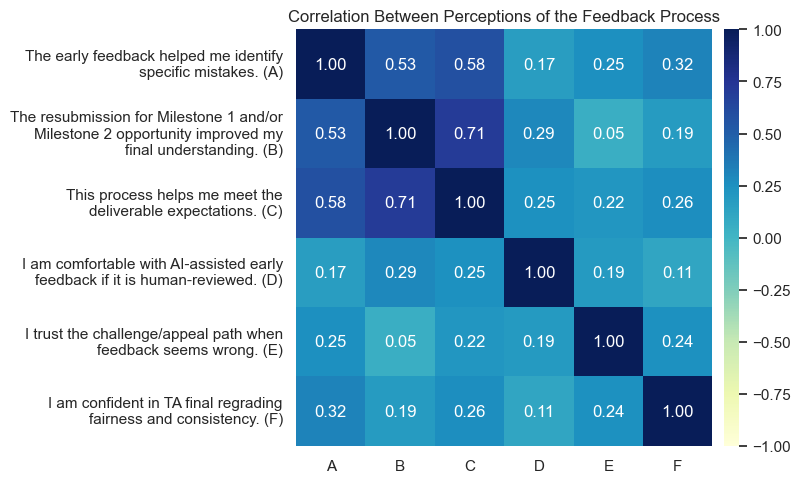

A) The early feedback helped me identify specific mistakes.
B) The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.
C) This process helps me meet the deliverable expectations.
D) I am comfortable with AI-assisted early feedback if it is human-reviewed.
E) I trust the challenge/appeal path when feedback seems wrong.
F) I am confident in TA final regrading fairness and consistency.


In [6]:
# Plot 4: Correlation heatmap among Likert items (sharing-eligible only)
# Convert Likert labels to numeric scale 1..5 using the leading number

from textwrap import fill
from mpl_toolkits.axes_grid1 import make_axes_locatable
import string

# Convert Likert labels to numeric scale 1..5 using leading number
likert_num = df_share[likert_cols].apply(
    lambda s: pd.to_numeric(s.str.extract(r"^(\d)")[0], errors="coerce")
)
corr = likert_num.corr()

# Build A, B, C... labels
letters = list(string.ascii_uppercase[:len(likert_cols)])
wrapped_y = [f"{fill(q, width=40)} ({letters[i]})" for i, q in enumerate(likert_cols)]
x_short = letters

# Bigger figure so wrapped y-labels fit
fig, ax = plt.subplots(figsize=(7, 5))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3.5%", pad=0.12)  # same height as heatmap

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    xticklabels=x_short,
    yticklabels=wrapped_y,
    ax=ax,
    cbar_ax=cax
)

ax.set_title("Correlation Between Perceptions of the Feedback Process")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# Optional key for A/B/C...
for i, q in enumerate(likert_cols):
    print(f"{letters[i]}) {q}")


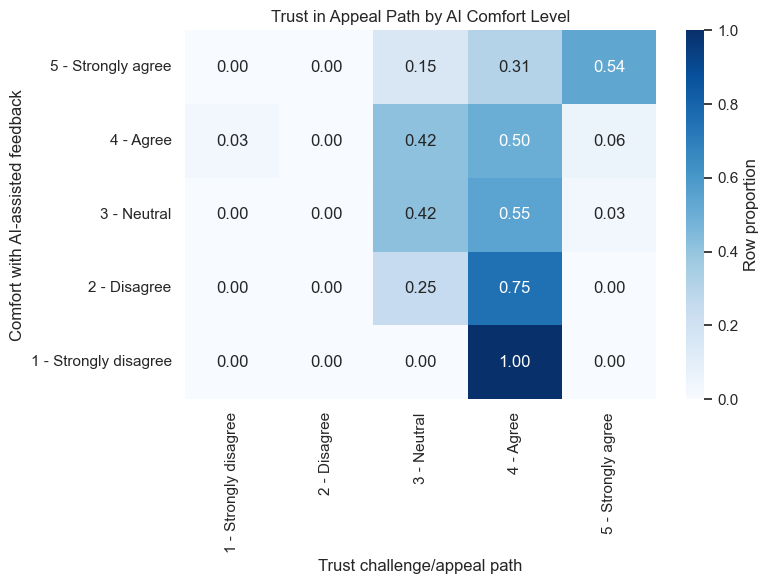

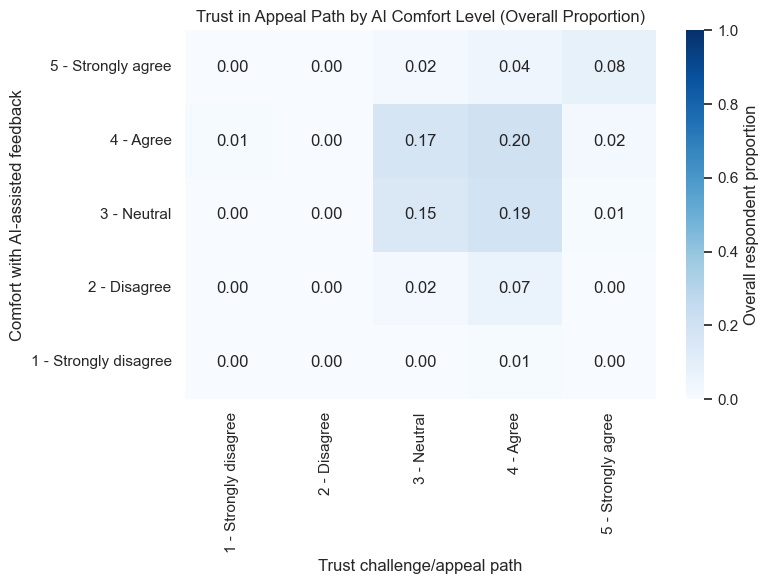

In [7]:
# Plot 5: Relationship between AI comfort and trust in challenge/appeal path
ai_col = "I am comfortable with AI-assisted early feedback if it is human-reviewed."
trust_col = "I trust the challenge/appeal path when feedback seems wrong."

y_order = likert_order[::-1]  # Strongly agree -> ... -> Strongly disagree

ct = pd.crosstab(df_share[ai_col], df_share[trust_col], normalize="index")
ct = ct.reindex(index=y_order, columns=likert_order, fill_value=0).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "Row proportion"}, vmin=0, vmax=1)
plt.title("Trust in Appeal Path by AI Comfort Level")
plt.xlabel("Trust challenge/appeal path")
plt.ylabel("Comfort with AI-assisted feedback")
# plt.grid(False)
plt.tight_layout()

plt.show()

# Same matrix with proportions over all respondents (not row-normalized)
ct_all = pd.crosstab(df_share[ai_col], df_share[trust_col], normalize="all")
ct_all = ct_all.reindex(index=y_order, columns=likert_order, fill_value=0).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(ct_all, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "Overall respondent proportion"}, vmin=0, vmax=1)
plt.title("Trust in Appeal Path by AI Comfort Level (Overall Proportion)")
plt.xlabel("Trust challenge/appeal path")
plt.ylabel("Comfort with AI-assisted feedback")
plt.tight_layout()
plt.show()


In [8]:
# Quick numeric summary for interpretation
print("Sharing-eligible sample size:", len(df_share))
print("Top preferred structure:")
print(df_share[pref_col].value_counts().head(3))

print("Average Likert scores (1-5):")
mean_scores = likert_num.mean().sort_values(ascending=False)
for k, v in mean_scores.items():
    print(f"- {k}: {v:.2f}")

Sharing-eligible sample size: 89
Top preferred structure:
Which feedback structure do you prefer overall for milestones?
Early feedback + resubmission    85
Hybrid/other approach             3
One submission only               1
Name: count, dtype: int64
Average Likert scores (1-5):
- The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.: 4.55
- This process helps me meet the deliverable expectations.: 4.38
- I am confident in TA final regrading fairness and consistency.: 4.16
- The early feedback helped me identify specific mistakes.: 4.11
- I trust the challenge/appeal path when feedback seems wrong.: 3.72
- I am comfortable with AI-assisted early feedback if it is human-reviewed.: 3.58


In [9]:
# If needed:
# !pip install -q sentence-transformers scikit-learn plotly

import numpy as np
import pandas as pd
import plotly.express as px
from textwrap import fill
from html import escape
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from urllib3.exceptions import NotOpenSSLWarning
import warnings
import re
warnings.resetwarnings()
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)
warnings.filterwarnings("ignore", category=NotOpenSSLWarning)


# ---------- 1) Open-ended columns ----------
open_ended_cols = [
    "How did the submit + quick detailed feedback + resubmission cycle affect your learning process?",
    "In what assignment scenarios would you NOT want this model (early feedback + resubmission)?",
    "Biggest advantage for you of bringing GenAI into early feedback:",
    "Biggest disadvantage for you of bringing GenAI into early feedback:",
    # "One concrete change you recommend for the next milestone feedback process:",
    "What else would you like to share with the instructor and TAs on this topic?"
]

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")


def analyze_open_ended(question_col, min_chars=12):
    s = df_share[question_col].dropna().astype(str).str.strip()
    s = s[s.str.len() >= min_chars]
    docs = s.tolist()
    docs = pd.Series(docs).dropna().astype(str).str.strip()
    docs = docs[docs.str.len() >= 5].drop_duplicates().tolist()


    print("\n" + "=" * 90)
    print(question_col)
    print(f"Usable responses: {len(docs)}")

    if len(docs) < 8:
        print("Too few responses for stable clustering/visualization. Skipping.")
        return

    # Embeddings
    emb = sentence_model.encode(
        docs,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)
    emb = np.ascontiguousarray(emb, dtype=np.float32)
    emb = np.nan_to_num(emb, nan=0.0, posinf=1.0, neginf=-1.0)
    perplexity = max(2, min(8, len(emb) - 1))

    # Agglomerative clusters
    n_clusters = min(6, max(2, int(np.sqrt(len(docs) / 2))))
    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward").fit_predict(emb)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity,
        init="random",
        learning_rate="auto",
        metric="euclidean",
        method="exact",
        max_iter=2000
    )
    xy = tsne.fit_transform(emb)

    plot_df = pd.DataFrame({
        "x": xy[:, 0],
        "y": xy[:, 1],
        "cluster": labels.astype(str),
        "doc_num": [f"Resp {i+1}" for i in range(len(docs))],
        "document": docs,
        "wrapped_doc": [fill(d, width=60).replace("\n", "<br>") for d in docs]
    }).sort_values("cluster")

    fig = px.scatter(
        plot_df,
        x="x",
        y="y",
        color="cluster",
        custom_data=["doc_num", "wrapped_doc", "cluster"],
        # title=f"t-SNE + Agglomerative: {question_col}",
        title=f"<b>{question_col}</b>",
        labels={"cluster": "Cluster"},
        category_orders={"cluster": [str(i) for i in range(n_clusters)]}
    )

    fig.update_traces(
        marker=dict(size=11, line=dict(width=1, color="white")),
        hovertemplate="<b>%{customdata[0]}</b><br>"
                      "Cluster: %{customdata[2]}<br><br>"
                      "%{customdata[1]}<br>"
                      "<extra></extra>"
    )
    fig.update_layout(width=900, height=550, hoverlabel=dict(align="left"))
    fig.show()

    # Cluster size summary
    size_df = (
        pd.Series(labels, name="cluster")
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="count")
    )
    size_df["pct"] = (size_df["count"] / size_df["count"].sum() * 100).round(1)
    display(size_df)

    # Cluster-unique clause mining (contrastive semantic scoring)
    # We extract sub-sentences and score each clause by how much closer it is to its
    # own cluster than to other clusters.
    clause_records = []
    split_pattern = re.compile(r"(?<=[.!?;:])\s+|\n+")

    for doc_i, text in enumerate(docs):
        parts = [p.strip(" -\t") for p in split_pattern.split(text)]
        for part in parts:
            if len(part) < 20:
                continue
            norm = re.sub(r"\s+", " ", part.lower()).strip()
            clause_records.append({
                "cluster": int(labels[doc_i]),
                "doc_idx": doc_i,
                "clause": part,
                "norm": norm,
            })

    clause_df = pd.DataFrame(clause_records)

    # Build cluster centroids from response embeddings (already normalized embeddings).
    cluster_ids = sorted(set(int(c) for c in labels))
    centroid_map = {}
    for c in cluster_ids:
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        v = emb[idx].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        centroid_map[c] = v

    cluster_top_unique_clauses = {c: [] for c in range(n_clusters)}
    ranking_rows = []

    if not clause_df.empty and centroid_map:
        clause_texts = clause_df["clause"].tolist()
        clause_emb = sentence_model.encode(
            clause_texts,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        ).astype(np.float64)
        clause_emb = np.ascontiguousarray(np.nan_to_num(clause_emb, nan=0.0, posinf=1.0, neginf=-1.0))

        centroid_ids = sorted(centroid_map.keys())
        centroid_mat = np.vstack([centroid_map[c] for c in centroid_ids]).astype(np.float64)
        centroid_mat = np.ascontiguousarray(np.nan_to_num(centroid_mat, nan=0.0, posinf=1.0, neginf=-1.0))

        # Stable cosine similarity without direct matrix-multiplication on this environment.
        clause_norm = np.linalg.norm(clause_emb, axis=1, keepdims=True)
        centroid_norm = np.linalg.norm(centroid_mat, axis=1, keepdims=True)
        clause_norm[~np.isfinite(clause_norm) | (clause_norm == 0)] = 1.0
        centroid_norm[~np.isfinite(centroid_norm) | (centroid_norm == 0)] = 1.0
        clause_emb = clause_emb / clause_norm
        centroid_mat = centroid_mat / centroid_norm

        sim_cols = [np.sum(clause_emb * centroid_mat[j], axis=1) for j in range(centroid_mat.shape[0])]
        sim_mat = np.column_stack(sim_cols).astype(np.float32)
        sim_mat = np.nan_to_num(sim_mat, nan=0.0, posinf=1.0, neginf=-1.0)

        centroid_col = {c: i for i, c in enumerate(centroid_ids)}

        own_col = clause_df["cluster"].map(centroid_col).to_numpy()
        own_sim = sim_mat[np.arange(len(clause_df)), own_col]

        max_other = np.empty(len(clause_df), dtype=np.float32)
        for i in range(len(clause_df)):
            row = sim_mat[i]
            j = own_col[i]
            if row.shape[0] <= 1:
                max_other[i] = -1.0
            else:
                max_other[i] = np.max(np.delete(row, j))

        clause_df["own_sim"] = own_sim
        clause_df["contrast"] = own_sim - max_other

        # Aggregate near-duplicate clauses inside each cluster.
        agg = (
            clause_df.groupby(["cluster", "norm"], as_index=False)
            .agg(
                clause=("clause", "first"),
                support=("doc_idx", "nunique"),
                mean_contrast=("contrast", "mean"),
                mean_own_sim=("own_sim", "mean"),
            )
        )
        agg["score"] = agg["mean_contrast"] + 0.04 * agg["support"]

        for c in range(n_clusters):
            idx = np.where(labels == c)[0]
            if len(idx) == 0:
                continue

            sub = agg[agg["cluster"] == c].copy()
            # Prefer phrases that appear in multiple responses; fallback if needed.
            sub2 = sub[sub["support"] >= 2].copy()
            if sub2.empty:
                sub2 = sub

            sub2 = sub2.sort_values(
                ["score", "mean_contrast", "support", "mean_own_sim"],
                ascending=False,
            )

            top_clauses = sub2["clause"].head(6).tolist()
            cluster_top_unique_clauses[c] = top_clauses

            for rank, clause in enumerate(top_clauses, start=1):
                ranking_rows.append({
                    "cluster": c,
                    "ranking": rank,
                    "top_unique_clause": clause,
                })

    ranking_df = pd.DataFrame(
        ranking_rows,
        columns=["cluster", "ranking", "top_unique_clause"],
    ).sort_values(["cluster", "ranking"])
    palette_rank = ["#E8F1FB", "#EAF7EA", "#FFF4E5", "#FDEBEC", "#EEF2FF", "#F2F2F2"]
    cluster_to_color_rank = {c: palette_rank[int(c) % len(palette_rank)] for c in sorted(ranking_df["cluster"].unique())}

    def color_rank_row(row):
        color = cluster_to_color_rank.get(row["cluster"], "#FFFFFF")
        return [f"background-color: {color}"] * len(row)

    display(
        ranking_df.style
        .apply(color_rank_row, axis=1)
        .set_properties(
            subset=["top_unique_clause"],
            **{
                "min-width": "200px",
                "max-width": "500px",
                "white-space": "normal",
                "text-align": "left",
            }
        )
    )

    # Representative responses (closest to each cluster mean embedding)
    rep_rows = []
    for c in range(n_clusters):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue

        # Compute a pseudo-centroid for this cluster and rank by cosine similarity.
        cluster_emb = emb[idx]
        centroid = cluster_emb.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_emb, centroid).ravel()
        top_local = np.argsort(sims)[::-1][:3]  # top 3 per cluster

        for rank, local_i in enumerate(top_local, start=1):
            global_i = idx[local_i]
            rep_rows.append({
                "cluster": c,
                "rank_in_cluster": rank,
                "response": docs[global_i]
            })

    rep_df = pd.DataFrame(rep_rows).sort_values(["cluster", "rank_in_cluster"]).copy()
    # rep_df["top_unique_clauses"] = rep_df["cluster"].map(lambda c: " || ".join(cluster_top_unique_clauses.get(c, [])[:4]))

    def bold_terms_in_text(text, terms):
        safe = escape(str(text))
        # Match longer phrases first to avoid partial overlaps.
        ordered_terms = sorted({t for t in terms if t}, key=len, reverse=True)
        for term in ordered_terms:
            safe_term = escape(term)
            pattern = re.compile(rf"(?i)({re.escape(safe_term)})")
            safe = pattern.sub(r"<b>\1</b>", safe)
        return safe

    rep_df["response"] = rep_df.apply(
        lambda r: bold_terms_in_text(r["response"], cluster_top_unique_clauses.get(r["cluster"], [])),
        axis=1,
    )

    # Color rows by cluster for quicker scanning.
    palette = ["#E8F1FB", "#EAF7EA", "#FFF4E5", "#FDEBEC", "#EEF2FF", "#F2F2F2"]
    cluster_to_color = {c: palette[int(c) % len(palette)] for c in sorted(rep_df["cluster"].unique())}

    def color_row(row):
        color = cluster_to_color.get(row["cluster"], "#FFFFFF")
        return [f"background-color: {color}"] * len(row)

    display(
        rep_df.style
        .apply(color_row, axis=1)
        .format({"response": lambda x: x}, escape=None)
        .set_properties(
            subset=["response"],
            **{"white-space": "normal", "text-align": "left", "max-width": "900px"}
        )
    )


# ---------- 2) Run all open-ended questions ----------
for col in open_ended_cols:
    analyze_open_ended(col)


/Users/belencsf/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



How did the submit + quick detailed feedback + resubmission cycle affect your learning process?
Usable responses: 89


,cluster,count,pct
0,0,22,24.7
1,1,16,18.0
2,2,9,10.1
3,3,25,28.1
4,4,9,10.1
5,5,8,9.0


,cluster,ranking,top_unique_clause
0,0,1,It is helpful because it gives me an opportunity to seek out help and guidance on a topic i thought i had grasped but didn't
1,0,2,It helped me identify exactly where I needed to improve and gave me clear guidance on how to make my work stronger.
2,0,3,I think it actually helped me learn a lot because it encouraged me to take a closer look at the work I was doing.
3,0,4,It allows us to see what we did wrong and highlight our mistakes and shows us what to fix and why.
4,0,5,It helped me learn from my mistakes and remember core concepts for future situations.
5,0,6,It gave me the opportunity to learn from my mistakes and improve on my learning.
6,1,1,"resubmission clarify what i was right and what i need to improve, thus more effective and have chance to better grade"
7,1,2,One thing that works really well for my learning (and grade) is getting something wrong and then getting feedback to rectify the mistake because I fully understand the concept and how to actually apply it.
8,1,3,I don't have to wait until the final grading stage to discover mistakes;
9,1,4,Getting feedback and having a chance to fix things made me actually understand where I went wrong rather than just accepting a grade.


,cluster,rank_in_cluster,response
0,0,1,It gave me the opportunity to learn from my mistakes and improve on my learning. It also motivated me to think more deeply about the content that we learn in class and how to best apply it to our group project. Having feedback is really useful since I can understand where I went wrong. I really like having this format and hope that we continue to have resubmission opportunities.
1,0,2,It gave me more insight and allowed me to understand better what I got wrong and how I can improve for later assignments. As well as areas i need to strengthen in my understanding of what i am being taught. It is helpful because it gives me an opportunity to seek out help and guidance on a topic i thought i had grasped but didn't
2,0,3,It affected my learning in a positive way because I was able to get feedback while the assignment was still fresh in my mind. That made it easier to understand what I did wrong and why. I didn’t feel confused trying to connect old work with new lessons we were already moving on to. Being able to quickly fix and resubmit my work helped me actually learn from my mistakes instead of just seeing a grade and moving on.
3,1,1,"The submit, feedback, resubmission cycle helped me learn from my mistakes instead of just moving on. Getting feedback and having a chance to fix things made me actually understand where I went wrong rather than just accepting a grade. It also made me more willing to try my best on the first attempt knowing I'd have a chance to improve if I missed something."
4,1,2,"One thing that works really well for my learning (and grade) is getting something wrong and then getting feedback to rectify the mistake because I fully understand the concept and how to actually apply it. Therefore, the feedback and resubmssion definitely contributed greatly to the learning process."
5,1,3,"The really helped me learn better. Getting quick feedback showed me exactly what I did wrong while it was still fresh, so I could fix it right away. Being able to try again made me focus more on improving, not just the grade, and I understood the material more. Over time, in the next milestone, I noticed I was repeating fewer mistakes and feeling more confident in the concepts."
6,2,1,"It made my learning much more concrete instead of theoretical. After Milestone 2, the feedback quickly pointed out exactly what was missing like rejecting blank strings for usernames/channel names, and keeping my Milestone 1 schema description consistent with my Milestone 2 SQL. Because the feedback came early and was specific, I could immediately test the fixes, rerun the schema checks, and confirm the behavior end-to-end. The resubmission mindset also helped me treat mistakes as part of building a reliable database. I started comparing my written schema and implemented SQL more carefully, and I paid more attention to small but important details like constraints, naming consistency, and evidence in reflections."
7,2,2,"This cycle allowed me to understand where there were gaps in my knowledge/understanding, and was really helpful. In feedback for milestone 1, it was helpful to get feedback on potential future issues even though they didn't mean loss of points for that milestone. Early feedback also allows me to ask questions before moving on to future milestones."
8,2,3,"The feedback in milestone 1 was a little hard to understand, but milestone two seems like it a was dense and started to get a little confusing but i managed. I think the submit and having the opportunity to resubmit help me go through everything again to get a better understanding of what went wrong and what needs to be done. I think this iteration model works well. Its just the feedback needs to be more clear and not as confusing."
9,3,1,"The submit + quick detailed feedback + resubmission cycle positively impacted my learning process by creating an immediate feedback loop. Instead of waiting too long to know what I did wrong, I was able to quic

...

,cluster,rank_in_cluster,response
0,0,1,"Maybe that it is less detailed, and that might not help us fix our mistakes."
1,0,2,Some issues that need human judgment or deeper understanding might not be noticed.
2,0,3,I am not sure possibly have it be inncorect or using outside information that we haven't learned
3,1,1,"Sometimes AI make mistakes, I can not guarantee my feedback is 100 percent correct."
4,1,2,AI can be wrong
5,1,3,Many times AI can be wrong.
6,2,1,"GenAI is not always accurate and is open to making mistakes because it may not have the enitre context or understanding of our course material, learning style, etc."
7,2,2,Sometimes the GenAI doesn't understand and I had to be very specific
8,2,3,"Sometimes, GenAI will get stuff wrong, and in that scenario it can be annoying to have to fix AI and make sure what it is saying is correct."
9,3,1,"One possible disadvantage is that it can make students rely too much on external help instead of fully thinking through problems on their own. If used too often, it might reduce independent problem-solving skills. It can also create confusion about what counts as appropriate use, especially in courses with strict AI policies."



What else would you like to share with the instructor and TAs on this topic?
Usable responses: 30


,cluster,count,pct
0,0,11,36.7
1,1,7,23.3
2,2,12,40.0


,cluster,ranking,top_unique_clause
0,0,1,The combination of AI-assisted early feedback and human review is very effective.
1,0,2,"Continuing to closely align feedback with the rating scale categories, if possible, would make the connection between modifications and performance expectations clearer."
2,0,3,"For Milestone 1, we received follow-up feedback after resubmitting, but the specific items that led to point deductions were not clearly highlighted in the first round of feedback."
3,0,4,"Without that transparency, it's hard to trust whether we are receiving genuine feedback from the team or just a copy-paste output."
4,0,5,"The quick feedback was the most valuable part, so keeping that fast turnaround is really important."
5,0,6,Maintaining clear separation between AI suggestions and TA judgment helps build trust and clarity.
6,1,1,"Nothing else, thank you for this quarter."
7,1,2,I do not have anything else to share at this time.
8,2,1,Thank you for the resubmission opportunity
9,2,2,"Thanks for offering resubmissions, it must be a lot of work to constantly regrade student's assignments so I really appreciate the care you put into the class and the commitment to our learning rather than the grade itself."


,cluster,rank_in_cluster,response
0,0,1,"Overall, the early feedback and resubmission process was very helpful. Clearer signals about priorities and common pitfalls across the class would make it even more effective, but I really appreciated the speed and specificity of the feedback."
1,0,2,"This early feedback model has been effective, not only in giving us the opportunity to improve, but also in providing insight into the course subject matter, and it has allowed the milestone assessment process to be more developmentally oriented than evaluative. Continuing to closely align feedback with the rating scale categories, if possible, would make the connection between modifications and performance expectations clearer. Additionally, I think being open and transparent about how GenAI will be used in the modification process helps reduce uncertainty and supports responsible use."
2,0,3,I really appreciated how supportive and learning-focused this feedback process felt. The quick turnaround and clear explanations made it easier to stay engaged and improve without feeling discouraged.
3,1,1,Nothing else.
4,1,2,nothing else
5,1,3,"Nothing else, thank you for this quarter."
6,2,1,"Thanks for offering resubmissions, it must be a lot of work to constantly regrade student's assignments so I really appreciate the care you put into the class and the commitment to our learning rather than the grade itself."
7,2,2,I really like this structure because it allows us to improve on our mistakes and really learn more in depth about the topic.
8,2,3,"The assignments can be somewhat difficult to understand the requirements, more detail and better organization in the instructions and a clear final statement of what is required for submission would be greatly appreciated."
